# Introduction
Purpose of this research is about how the students' grades are effected by the kind of food, eating habit and other personal lifestyle. And vice versa, how food effects the students in general. 

The dataset is obtained from Mercyhurst University interview with 126 university students and from their responds. 

Data itself is raw and uncleaned and I believe this is a good oppotunity to learn about NLP. Data size also fitted within the suggested option. So, the objective of this project is to clean the raw data. 

# Relevance
For this research project dataset, I obtained it from <a href="https://www.kaggle.com/datasets/borapajo/food-choices"> Kaggle </a>. There are other related dataset regarding with this topic, however, they are the studies about <a href="https://www.kaggle.com/datasets/impapan/student-performance-data-set">primary, secondary schooler</a> or <a href="https://www.kaggle.com/datasets/dillonmyrick/high-school-student-performance-and-demographics/data"> high school students </a> and not about university students. Since I wanted to do something releated with university students, those datasets are eliminated. There are other datasets about <a href="https://www.kaggle.com/datasets/openfoodfacts/world-food-facts"> general population with food consumption </a> but the data size is huge. Regarding with <a href="https://www.kaggle.com/datasets/joebeachcapital/food-waste">food waste</a> dataset, the data itself is too simple with no challenges. So the chosen dataset is the best fit for the project.

# Project Background

- Since I am also a university student, I am eager to know how the food consuming have impact on our performance on the school work. 
- Dataset provider does the interview out of interest but with that said the data itself is raw and uncleaned which means answers are not being discorvered yet. There are some inspiration question stated on the website but they are not answered and also no update is made by the time this project is submitted. I would also be using some of the inspirated question from the dataset provider to find out the interseting pattern and relativeness.
- In the dataset, there are irrelevant questions regarding with the project such as in the heading 'meals_dinner_friend', "what would you serve to friend for dinner?" and etc are eliminated. Since it does not provide any relevance with the objective of this project as in the person here is not the consumer itself but the person he/she treat to.
- Initially, I tried to roughly divide into 3 categories, 

1. Demographic
2. Cooking Habits by parents
3. Eating habits after getting into college
4. Other habits affecting the GPA

And some of the questions came from the dataset provider itself since the questions are not being answered or discovered yet.

In [1]:
import pandas as pd
df = pd.read_csv('food_coded.csv')
df.head(5)

,GPA,Gender,breakfast,calories_chicken,calories_day,calories_scone,coffee,comfort_food,comfort_food_reasons,comfort_food_reasons_coded,...,soup,sports,thai_food,tortilla_calories,turkey_calories,type_sports,veggies_day,vitamins,waffle_calories,weight
0,2.4,2,1,430,NaN,315.0,1,none,we dont have comfort,9.0,...,1.0,1.0,1,1165.0,345,car racing,5,1,1315,187
1,3.654,1,1,610,3.0,420.0,2,"chocolate, chips, ice cream","Stress, bored, anger",1.0,...,1.0,1.0,2,725.0,690,Basketball,4,2,900,155
2,3.3,1,1,720,4.0,420.0,2,"frozen yogurt, pizza, fast food","stress, sadness",1.0,...,1.0,2.0,5,1165.0,500,none,5,1,900,I'm not answering this.
3,3.2,1,1,430,3.0,420.0,2,"Pizza, Mac and cheese, ice cream",Boredom,2.0,...,1.0,2.0,5,725.0,690,NaN,3,1,1315,"Not sure, 240"
4,3.5,1,1,720,2.0,420.0,2,"Ice cream, chocolate, chips","Stress, boredom, cravings",1.0,...,1.0,1.0,4,940.0,500,Softball,4,2,760,190


Originally, there are a total of 126 rows (students) and 61 columns (informations, 1 column for numbering)

After observing the top 10 rows of the file, the data is pretty messy. 
- Most of them are open ended questions which is a bunch of strings with commars. 
- NaN values. 
- Some data are useful and interesting but they are in unrelated format/datatype
- Some columns are not necessay for this project, for example, in **breakfast** column, showing 2 pictures of 2 different kind of coffee but the answers in either number 1 or 2.

In [3]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125 entries, 0 to 124
Data columns (total 61 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   GPA                           123 non-null    object 
 1   Gender                        125 non-null    int64  
 2   breakfast                     125 non-null    int64  
 3   calories_chicken              125 non-null    int64  
 4   calories_day                  106 non-null    float64
 5   calories_scone                124 non-null    float64
 6   coffee                        125 non-null    int64  
 7   comfort_food                  124 non-null    object 
 8   comfort_food_reasons          123 non-null    object 
 9   comfort_food_reasons_coded    106 non-null    float64
 10  cook                          122 non-null    float64
 11  comfort_food_reasons_coded.1  125 non-null    int64  
 12  cuisine                       108 non-null    float64
 13  diet_

Checking the datatype of each column to make sure the datatype in order to do data cleaning in the following.

In [4]:
df = df.drop_duplicates()
df

,GPA,Gender,breakfast,calories_chicken,calories_day,calories_scone,coffee,comfort_food,comfort_food_reasons,comfort_food_reasons_coded,...,soup,sports,thai_food,tortilla_calories,turkey_calories,type_sports,veggies_day,vitamins,waffle_calories,weight
0,2.4,2,1,430,NaN,315.0,1,none,we dont have comfort,9.0,...,1.0,1.0,1,1165.0,345,car racing,5,1,1315,187
1,3.654,1,1,610,3.0,420.0,2,"chocolate, chips, ice cream","Stress, bored, anger",1.0,...,1.0,1.0,2,725.0,690,Basketball,4,2,900,155
2,3.3,1,1,720,4.0,420.0,2,"frozen yogurt, pizza, fast food","stress, sadness",1.0,...,1.0,2.0,5,1165.0,500,none,5,1,900,I'm not answering this.
3,3.2,1,1,430,3.0,420.0,2,"Pizza, Mac and cheese, ice cream",Boredom,2.0,...,1.0,2.0,5,725.0,690,NaN,3,1,1315,"Not sure, 240"
4,3.5,1,1,720,2.0,420.0,2,"Ice cream, chocolate, chips","Stress, boredom, cravings",1.0,...,1.0,1.0,4,940.0,500,Softball,4,2,760,190
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
120,3.5,1,1,610,4.0,420.0,2,"wine. mac and cheese, pizza, ice cream",boredom and sadness,NaN,...,1.0,1.0,5,940.0,500,Softball,5,1,1315,156
121,3,1,1,265,2.0,315.0,2,Pizza / Wings / Cheesecake,Loneliness / Homesick / Sadness,NaN,...,1.0,NaN,4,940.0,500,basketball,5,2,1315,180
122,3.882,1,1,720,NaN,420.0,1,"rice, potato, seaweed soup",sadness,NaN,...,1.0,2.0,5,580.0,690,none,4,2,1315,120
123,3,2,1,720,4.0,420.0,1,"Mac n Cheese, Lasagna, Pizza","happiness, they are some of my favorite foods",NaN,...,2.0,2.0,1,940.0,500,NaN,3,1,1315,135


seems like there is no duplicate in this dataset

There are some columns (19 columns) which are not related for this project. These columns are as belows,
1. breakfast 
2. comfort_food
3. comfort_food_reasons
4. comfort_food_reasons_coded
5. drink
6. ethnic_food
7. father_profession
8. fries
9. greek_food
10. ideal_diet
11. indian_food
12. italian_food
13. life_rewarding
14. marital_status
15. meals_dinner_friend
16. mothers_profession
17. persian_food
18. soup
19. thai_food

After doing the overall data cleaning, from this point on, we will do the data visulization together with the related necessary data cleaning.

In [5]:
df = df.drop(columns = ["breakfast", "comfort_food", "comfort_food_reasons", "comfort_food_reasons_coded", "drink", "ethnic_food", "father_profession", "fries", "greek_food", "ideal_diet", "indian_food", "italian_food", "life_rewarding", "marital_status", "meals_dinner_friend", "mother_profession", "persian_food", "soup", "thai_food"])
df

,GPA,Gender,calories_chicken,calories_day,calories_scone,coffee,cook,comfort_food_reasons_coded.1,cuisine,diet_current,...,pay_meal_out,self_perception_weight,sports,tortilla_calories,turkey_calories,type_sports,veggies_day,vitamins,waffle_calories,weight
0,2.4,2,430,NaN,315.0,1,2.0,9,NaN,eat good and exercise,...,2,3.0,1.0,1165.0,345,car racing,5,1,1315,187
1,3.654,1,610,3.0,420.0,2,3.0,1,1.0,I eat about three times a day with some snacks...,...,4,3.0,1.0,725.0,690,Basketball,4,2,900,155
2,3.3,1,720,4.0,420.0,2,1.0,1,3.0,"toast and fruit for breakfast, salad for lunch...",...,3,6.0,2.0,1165.0,500,none,5,1,900,I'm not answering this.
3,3.2,1,430,3.0,420.0,2,2.0,2,2.0,"College diet, cheap and easy foods most nights...",...,2,5.0,2.0,725.0,690,NaN,3,1,1315,"Not sure, 240"
4,3.5,1,720,2.0,420.0,2,1.0,1,2.0,I try to eat healthy but often struggle becaus...,...,4,4.0,1.0,940.0,500,Softball,4,2,760,190
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
120,3.5,1,610,4.0,420.0,2,3.0,2,1.0,"My diet consists mainly of coffee, water, frui...",...,4,4.0,1.0,940.0,500,Softball,5,1,1315,156
121,3,1,265,2.0,315.0,2,3.0,3,NaN,A college student with an imbalanced diet tryi...,...,4,4.0,NaN,940.0,500,basketball,5,2,1315,180
122,3.882,1,720,NaN,420.0,1,3.0,3,NaN,"Rice, oatmeal, and tea",...,4,4.0,2.0,580.0,690,none,4,2,1315,120
123,3,2,720,4.0,420.0,1,3.0,7,1.0,I try to eat as healthy as possible everyday. ...,...,3,2.0,2.0,940.0,500,NaN,3,1,1315,135


# Demographic
Let's take a look at the survey demographic in order to avoid biases towards a certain group.

In [6]:
selected_columns = ['Gender', 'employment', 'grade_level', 'income', 'weight']
df_selected = df[selected_columns]
df_selected.head(50)

,Gender,employment,grade_level,income,weight
0,2,3.0,2,5.0,187
1,1,2.0,4,4.0,155
2,1,3.0,3,6.0,I'm not answering this.
3,1,3.0,4,6.0,"Not sure, 240"
4,1,2.0,4,6.0,190
5,1,3.0,2,1.0,190
6,2,3.0,4,4.0,180
7,1,2.0,2,5.0,137
8,1,2.0,1,5.0,180
9,1,3.0,1,4.0,125


After observing 50 students, **'Gender', 'grade_level' and 'income'** columns are cleaned. However, they are in numbers which is uncleared to us if we do not have access to the original CSV file. 

Let's substitute these numbers with meaningful strings.

In [7]:
gender= {1: 'Female', 2: 'Male'}
grade_level = {1: 'Freshman', 2:'Sophomore', 3:'Junior', 4:'Senior'}
income = {1:'> $15,000', 2:'>$30,000', 3:'>$50,000', 4:'>$70,000', 5:'>$100,000', 6:'higher than $100,000'}


df['Gender'] = df['Gender'].replace(gender)
df['grade_level'] = df['grade_level'].replace(grade_level)
df['income'] = df['income'].replace(income)

selected_columns = ['Gender', 'grade_level', 'income']
df_selected = df[selected_columns]
df_selected.head(10)

,Gender,grade_level,income
0,Male,Sophomore,">$100,000"
1,Female,Senior,">$70,000"
2,Female,Junior,"higher than $100,000"
3,Female,Senior,"higher than $100,000"
4,Female,Senior,"higher than $100,000"
5,Female,Sophomore,"> $15,000"
6,Male,Senior,">$70,000"
7,Female,Sophomore,">$100,000"
8,Female,Freshman,">$100,000"
9,Female,Freshman,">$70,000"


**'employment'** columns has some NaN values and string. 

Let's replace the NaN value with 4, which is Others

Then, replacing these numbers into meaningful strings

In [8]:
df['employment'] = df['employment'].fillna(4).astype(int)

selected_columns = ['employment']
df_selected = df[selected_columns]
df_selected.head(50)

,employment
0,3
1,2
2,3
3,3
4,2
5,3
6,3
7,2
8,2
9,3


In [9]:
df['employment'] = df['employment'].map({1: 'Full Time', 2: 'Part Time', 3: 'Not Working', 4: 'Others'})

selected_columns = ['employment']
df_selected = df[selected_columns]
df_selected.head(10)

,employment
0,Not Working
1,Part Time
2,Not Working
3,Not Working
4,Part Time
5,Not Working
6,Not Working
7,Part Time
8,Part Time
9,Not Working


Now moved on with **weight** column

In [10]:
selected_columns = ['weight']
df_selected = df[selected_columns]
df_selected.head(50)

,weight
0,187
1,155
2,I'm not answering this.
3,"Not sure, 240"
4,190
5,190
6,180
7,137
8,180
9,125


In this 'weight' column, there are some strings and NaN value.

First, replace these strings into NaN value and then replaced these NaN value with the average weight.

In [11]:
df['weight'] = pd.to_numeric(df['weight'], errors='coerce')

selected_columns = ['weight']
df_selected = df[selected_columns]
df_selected.head(100)

,weight
0,187.0
1,155.0
2,NaN
3,NaN
4,190.0
...,...
95,184.0
96,210.0
97,155.0
98,185.0


In [12]:
mean_weight = df['weight'].mean()
print(f"Average weight is: {mean_weight}")

Average weight is: 158.5


In [13]:
df['weight'] = pd.to_numeric(df['weight'], errors='coerce').fillna(158.5)

selected_columns = ['weight']
df_selected = df[selected_columns]
df_selected.head(100)

,weight
0,187.0
1,155.0
2,158.5
3,158.5
4,190.0
...,...
95,184.0
96,210.0
97,155.0
98,185.0


After all the data cleaning, let's view the Demographic in terms of pie chart

In [12]:
import matplotlib.pyplot as plt

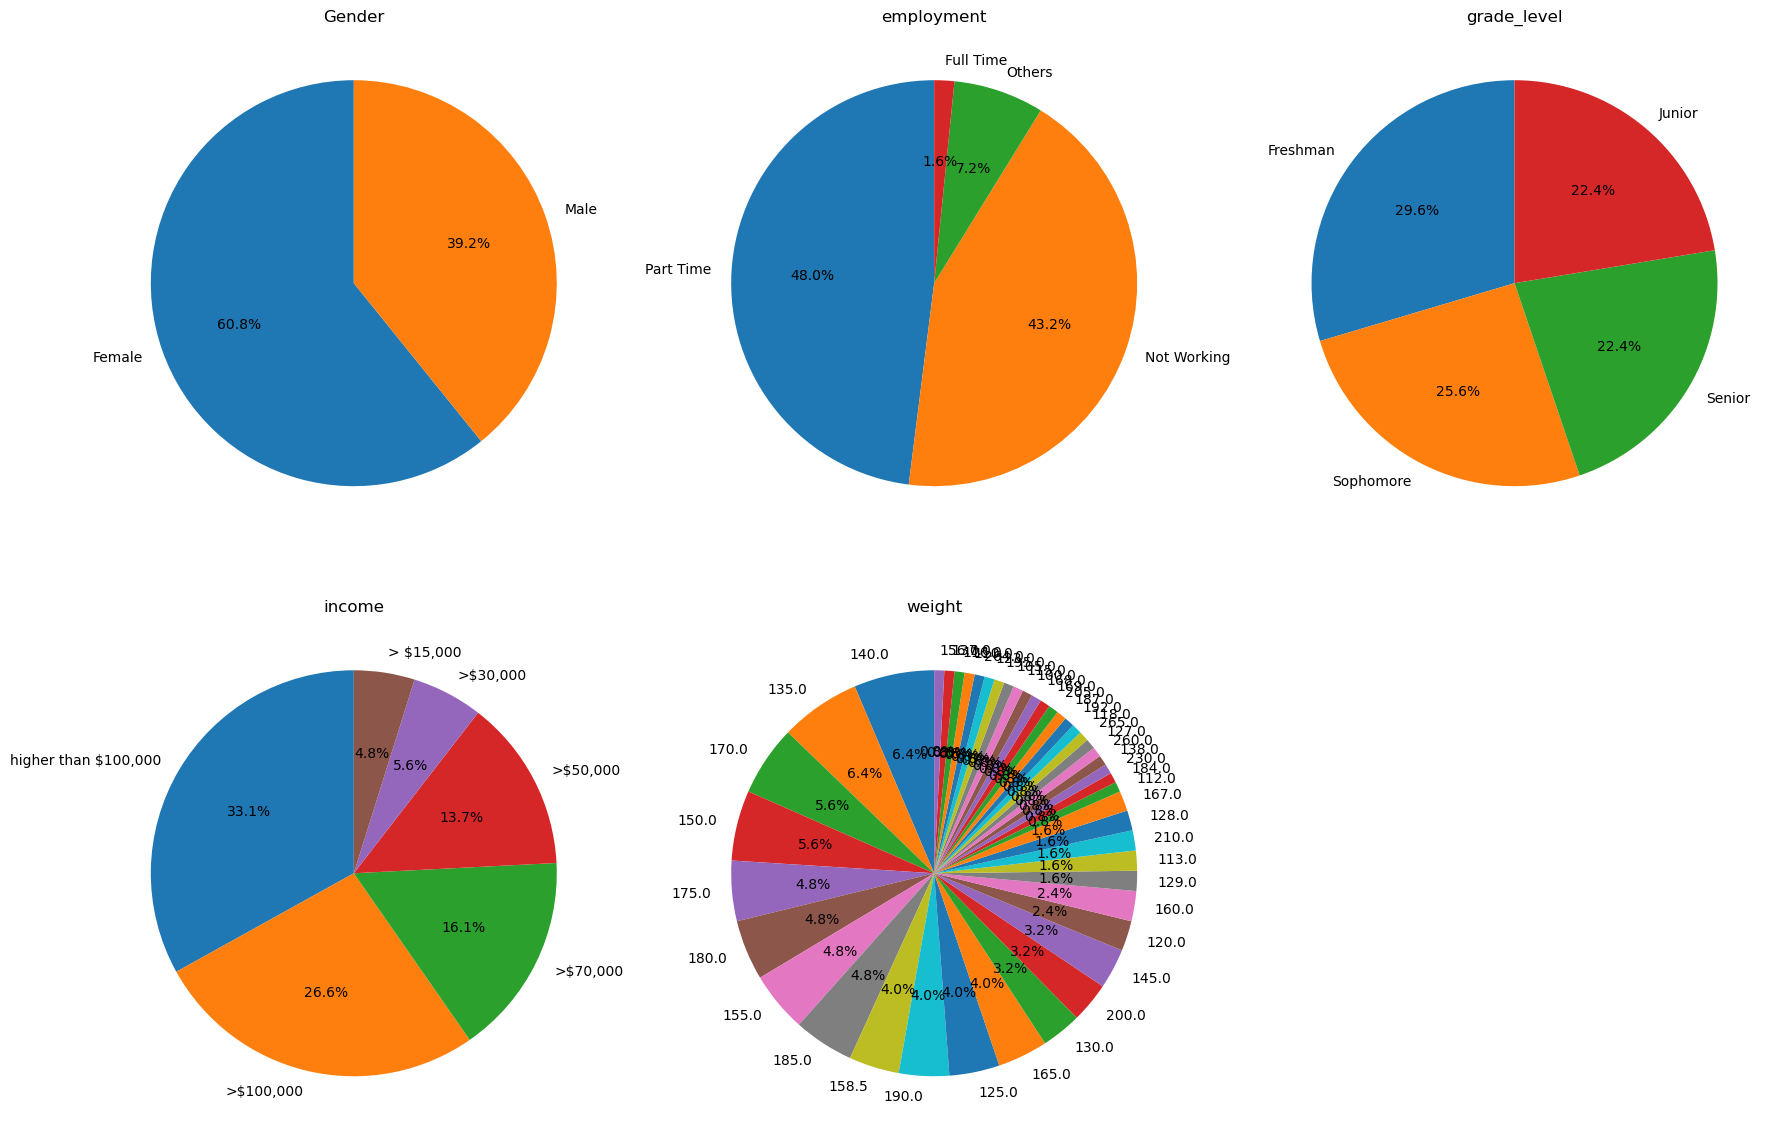

In [15]:
def create_pie_chart(column_name, subplot_index):
    plt.subplot(2, 3, subplot_index)
    column_counts = df[column_name].value_counts()
    plt.pie(column_counts, labels=column_counts.index, autopct='%1.1f%%', startangle=90)
    plt.title(f'{column_name}')

# Set up a figure with a 2x3 grid for subplots
plt.figure(figsize=(18, 12))

columns_to_plot = ['Gender', 'employment', 'grade_level', 'income', 'weight']
for index, column in enumerate(columns_to_plot, start=1):
    create_pie_chart(column, index)

plt.tight_layout()
plt.show()

From the above 5 pie charts, we can see this survey is done with a good mixed of demographic.

# Cooking Pattern
Now we want to check whether these student cook or not based on their parents. Does their parents' habit affect on their child?

In [16]:
selected_columns = ['cook', 'parents_cook']
df_selected = df[selected_columns]
df_selected.head(90)

,cook,parents_cook
0,2.0,1
1,3.0,1
2,1.0,1
3,2.0,1
4,1.0,1
...,...,...
85,3.0,2
86,2.0,1
87,4.0,1
88,NaN,1


Let's start with data cleaning and replacing these float and integer into meaningful strings

In [17]:
df['cook'] = df['cook'].astype(str)

cook = {'0.0':'Never, I do not know my way around a kitchen','1.0': 'Everyday', '2.0': 'A couple of times a week', '3.0': 'Whenever I can, but not often', '4.0': 'I only help a little during holidays', '5.0':'Never, I do not know my way around a kitchen'}
parents_cook = {1:'Almost everyday', 2:'2-3 times a week', 3:'1-2 times a week', 4:'on holiday only', 5:'Never'}

df['cook'] = df['cook'].replace(cook)
df['parents_cook'] = df['parents_cook'].replace(parents_cook)

selected_columns = ['cook', 'parents_cook']
df_selected = df[selected_columns]
df_selected.head(90)

,cook,parents_cook
0,A couple of times a week,Almost everyday
1,"Whenever I can, but not often",Almost everyday
2,Everyday,Almost everyday
3,A couple of times a week,Almost everyday
4,Everyday,Almost everyday
...,...,...
85,"Whenever I can, but not often",2-3 times a week
86,A couple of times a week,Almost everyday
87,I only help a little during holidays,Almost everyday
88,nan,Almost everyday


C:\Users\Aurora\AppData\Local\Temp\ipykernel_5636\2995595214.py:9: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


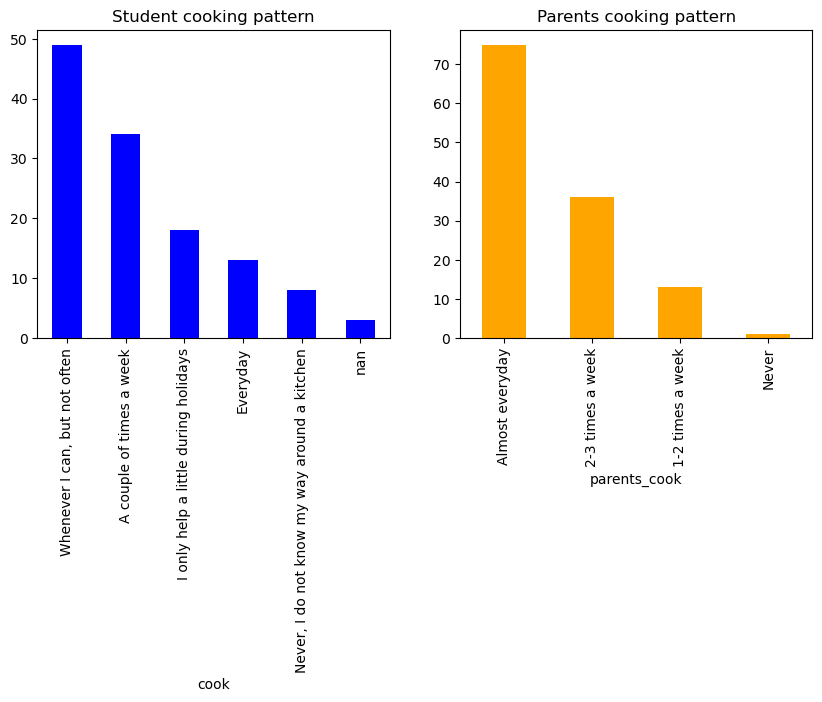

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))  # 1 row, 2 columns

# Plot the first bar graph
df['cook'].value_counts().plot(kind='bar', ax=axes[0], color='blue', title='Student cooking pattern')

# Plot the second bar graph
df['parents_cook'].value_counts().plot(kind='bar', ax=axes[1], color='orange', title='Parents cooking pattern')

plt.tight_layout()
plt.show()

From the above bar graph, it is very visible that parents' habit affects their children cooking pattern. Since we all know, homecook meals are way more healthier and clean than takeaways, parents who put an effort in cooking habit and make used to it can leads to their children. 

However, we cannot assume this entirely. There are less than 5 parents who never cook which is relatively low in number (total is 126, so less than 5%). But more than 10 students do not cook which is double in number. 

But from those who cook (both students and parents), the rest of the bar graphs show the similar number.

# Eating Habit After Getting into College

From one of the open ended question about how is the eating habit going after getting into college, we want to analyze and visualize them in terms of words.

In [20]:
from wordcloud import WordCloud

After ramdonly gather 5 answers from an open ended question to display a visual narrative.

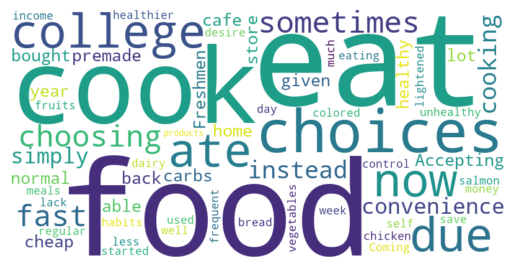

In [23]:
sentences = [
    'sometimes choosing to eat fast food instead of cooking simply for convenience.',
    'Accepting cheap and premade/store bought foods',
    'I cook a lot of my own foods back at home so not being able to cook my own healthy choices. I eat more carbs than normal when I am at college due to the choices given in the cafe.',
    'Freshmen year i ate very unhealthy, but now it is much healthier because of self control.',
    'Coming to college I have ate less well colored meals each day due to lack of income and desire to save money. I used to eat more fruits and vegetables, more chicken and salmon, now these habits have lightened up and are not as frequent and regular in the week. I have also started eating more bread and dairy products.'
]

# Create and generate a word cloud image:
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(full_text)

# Display the generated image:
plt.imshow(wordcloud, interpolation='bilinear')

# Bilinear interpolation is a way to spread the words out without them bumping into one another
plt.axis("off")
plt.show()

In [25]:
from nltk.tokenize import word_tokenize
from nltk.probability import FreqDist
import matplotlib.pyplot as plt
import nltk

Based on the eating habit since the start of college, let's analyze the postive and negative.

In [26]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer

nltk.download('vader_lexicon')

analyzer=SentimentIntensityAnalyzer()

sentences = [
    'sometimes choosing to eat fast food instead of cooking simply for convenience.',
    'Accepting cheap and premade/store bought foods',
    'I cook a lot of my own foods back at home so not being able to cook my own healthy choices. I eat more carbs than normal when I am at college due to the choices given in the cafe.',
    'Freshmen year i ate very unhealthy, but now it is much healthier because of self control.',
    'Coming to college I have ate less well colored meals each day due to lack of income and desire to save money. I used to eat more fruits and vegetables, more chicken and salmon, now these habits have lightened up and are not as frequent and regular in the week. I have also started eating more bread and dairy products.'
]

for sentence in sentences:
    sentiment_scores = analyzer.polarity_scores(sentence)
    print(f"Sentence: {sentence}")
    print(f"Sentiment Scores: {sentiment_scores}")

Sentence: sometimes choosing to eat fast food instead of cooking simply for convenience.
Sentiment Scores: {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}
Sentence: Accepting cheap and premade/store bought foods
Sentiment Scores: {'neg': 0.0, 'neu': 0.658, 'pos': 0.342, 'compound': 0.3818}
Sentence: I cook a lot of my own foods back at home so not being able to cook my own healthy choices. I eat more carbs than normal when I am at college due to the choices given in the cafe.
Sentiment Scores: {'neg': 0.0, 'neu': 0.928, 'pos': 0.072, 'compound': 0.4019}
Sentence: Freshmen year i ate very unhealthy, but now it is much healthier because of self control.
Sentiment Scores: {'neg': 0.144, 'neu': 0.856, 'pos': 0.0, 'compound': -0.3284}
Sentence: Coming to college I have ate less well colored meals each day due to lack of income and desire to save money. I used to eat more fruits and vegetables, more chicken and salmon, now these habits have lightened up and are not as frequent and regu

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\Aurora\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [27]:
open_ended_q=[""] * 5

open_ended_q[0] = "sometimes choosing to eat fast food instead of cooking simply for convenience."
open_ended_q[1] = "Accepting cheap and premade/store bought foods"
open_ended_q[2] = "I cook a lot of my own foods back at home so not being able to cook my own healthy choices. I eat more carbs than normal when I am at college due to the choices given in the cafe."
open_ended_q[3] = "Freshmen year i ate very unhealthy, but now it is much healthier because of self control."
open_ended_q[4] = "Coming to college I have ate less well colored meals each day due to lack of income and desire to save money. I used to eat more fruits and vegetables, more chicken and salmon, now these habits have lightened up and are not as frequent and regular in the week. I have also started eating more bread and dairy products."

def plotfreq(x, title=""):
    flat = []
    for i in x:
        flat += i
        
    f = nltk.FreqDist(flat)
    
    # Plot freq dist
    plt.figure(figsize=(12,3))
    
    plt.title(title)
    f.plot()

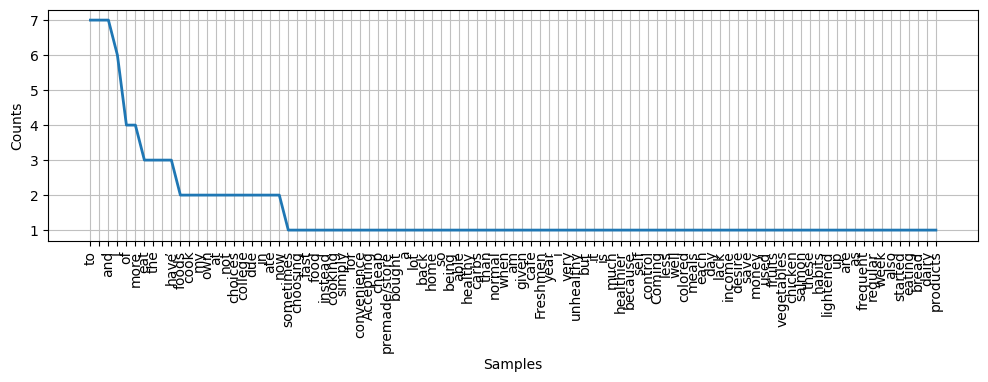

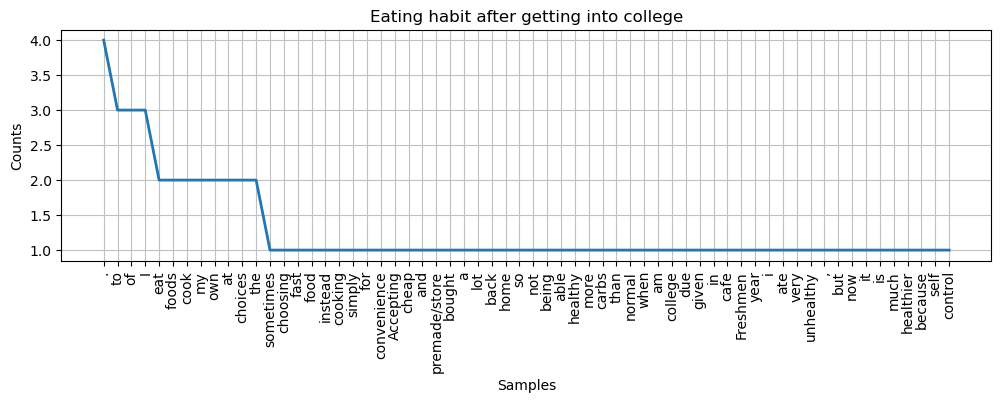

In [28]:
tokens = []
for open_ended in open_ended_q:
    words = word_tokenize(open_ended)
    tokens.append(words)

plotfreq(tokens)
plotfreq(tokens[0:4], "Eating habit after getting into college")

Let's remove punctuation

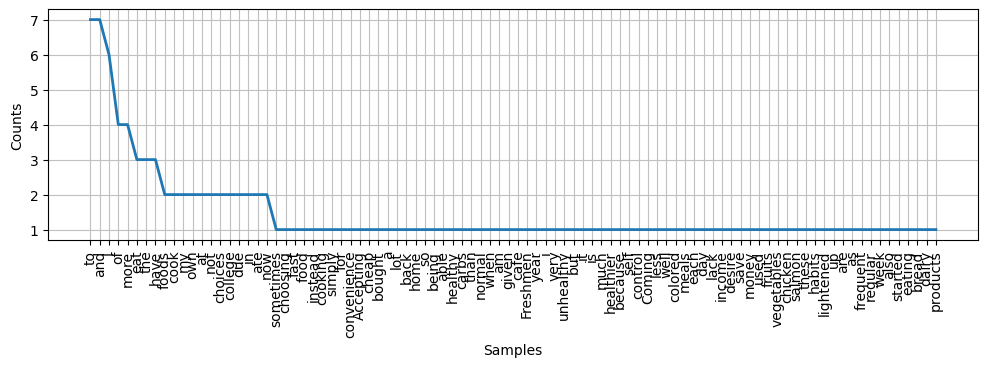

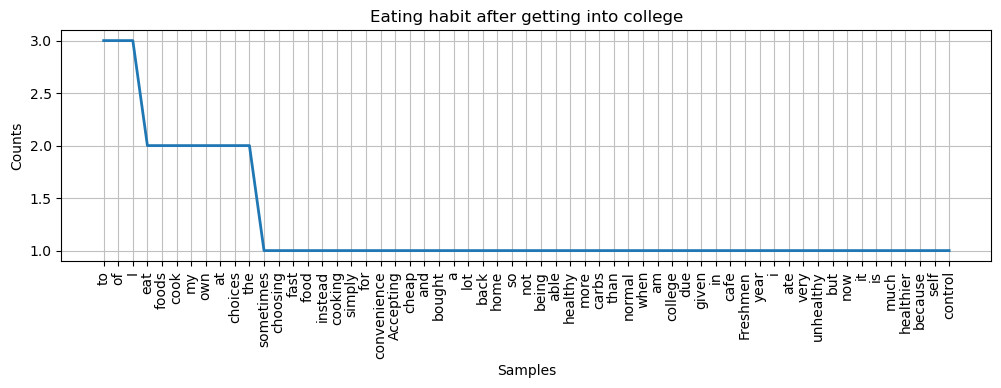

In [29]:
cleaned_tokens = []
for t in tokens:
    cleaned = [word for word in t if word.isalpha()]
    cleaned_tokens.append(cleaned)

plotfreq(cleaned_tokens)
plotfreq(cleaned_tokens[0:4], "Eating habit after getting into college") # dancers

Let's remove stopwords

['i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves', 'you', "you're", "you've", "you'll", "you'd", 'your', 'yours', 'yourself', 'yourselves', 'he', 'him', 'his', 'himself', 'she', "she's", 'her', 'hers', 'herself', 'it', "it's", 'its', 'itself', 'they', 'them', 'their', 'theirs', 'themselves', 'what', 'which', 'who', 'whom', 'this', 'that', "that'll", 'these', 'those', 'am', 'is', 'are', 'was', 'were', 'be', 'been', 'being', 'have', 'has', 'had', 'having', 'do', 'does', 'did', 'doing', 'a', 'an', 'the', 'and', 'but', 'if', 'or', 'because', 'as', 'until', 'while', 'of', 'at', 'by', 'for', 'with', 'about', 'against', 'between', 'into', 'through', 'during', 'before', 'after', 'above', 'below', 'to', 'from', 'up', 'down', 'in', 'out', 'on', 'off', 'over', 'under', 'again', 'further', 'then', 'once', 'here', 'there', 'when', 'where', 'why', 'how', 'all', 'any', 'both', 'each', 'few', 'more', 'most', 'other', 'some', 'such', 'no', 'nor', 'not', 'only', 'own', 'same', 'so', 'than', '

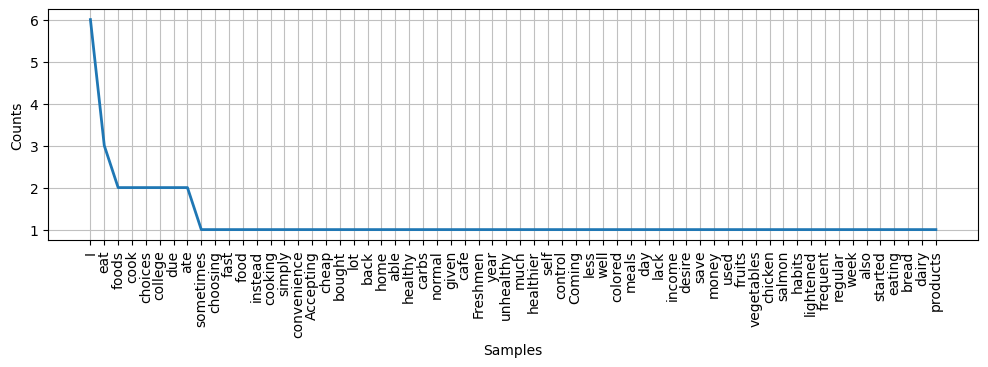

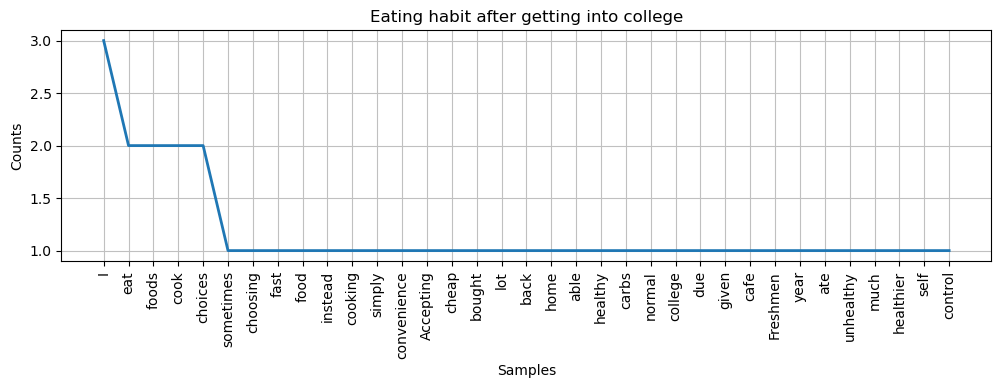

In [30]:
from nltk.corpus import stopwords
stop_words = stopwords.words('english')
print(stop_words)

# remove stopwords
stopwords_removed_tokens = []
for t in cleaned_tokens:
    cleaned = [word for word in t if not word in stop_words]
    stopwords_removed_tokens.append(cleaned)

plotfreq(stopwords_removed_tokens)
plotfreq(stopwords_removed_tokens[0:4], "Eating habit after getting into college")

Let's do stemming

Only Porter Stemmer is used to do the mild stemming

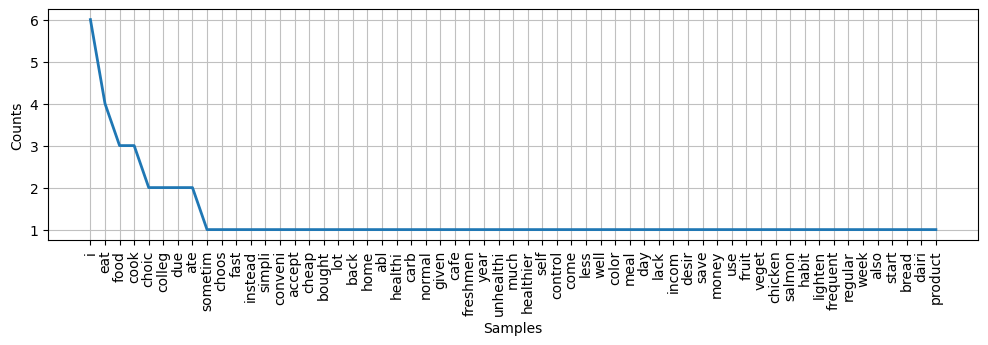

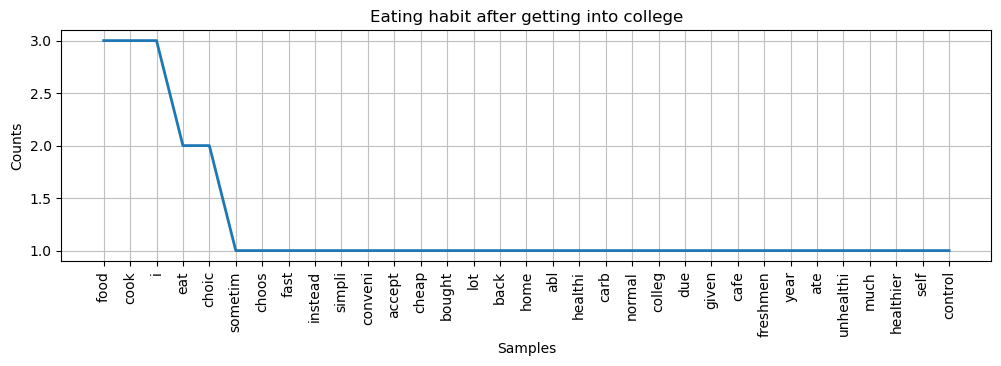

In [33]:
from nltk.stem import PorterStemmer
ps = PorterStemmer()
stemmed_tokens = []
for t in stopwords_removed_tokens:
    cleaned = [ps.stem(word) for word in t]
    stemmed_tokens.append(cleaned)
    
plotfreq(stemmed_tokens)
plotfreq(stemmed_tokens[0:4], "Eating habit after getting into college")

Seems like there is still 'i' left.

Overall, the eating habit seems to be neutral from analyzing with wordCloud, stemming and word tokenize.

However, from our point of view as human readers, after reading the randomly picked 5 sentences, we know it is negative.

Let's do further investigation in terms of real numbers!!
In the following 2 more questions, 
1. Ask how does the eating habit change in terms of worse, better, same or unclear
2. Ask how the eating habit change in detail (include 13 choices)

In [35]:
selected_columns = ['eating_changes_coded', 'eating_changes_coded1']
df_selected = df[selected_columns]
df_selected.head(10)

,eating_changes_coded,eating_changes_coded1
0,1,1
1,1,2
2,1,3
3,1,3
4,3,4
5,1,3
6,2,5
7,2,5
8,2,8
9,1,3


Data for these 2 columns is clean. So, let's replace these numbers with meaningful strings

In [9]:
eating_changes_coded = {1:'Worst', 2:'Better', 3:'Same', 4:'Unclear'}
df['eating_changes_coded'] = df['eating_changes_coded'].replace(eating_changes_coded)

selected_columns = ['eating_changes_coded']
df_selected = df[selected_columns]
df_selected.head(10)

,eating_changes_coded
0,Worst
1,Worst
2,Worst
3,Worst
4,Same
5,Worst
6,Better
7,Better
8,Better
9,Worst


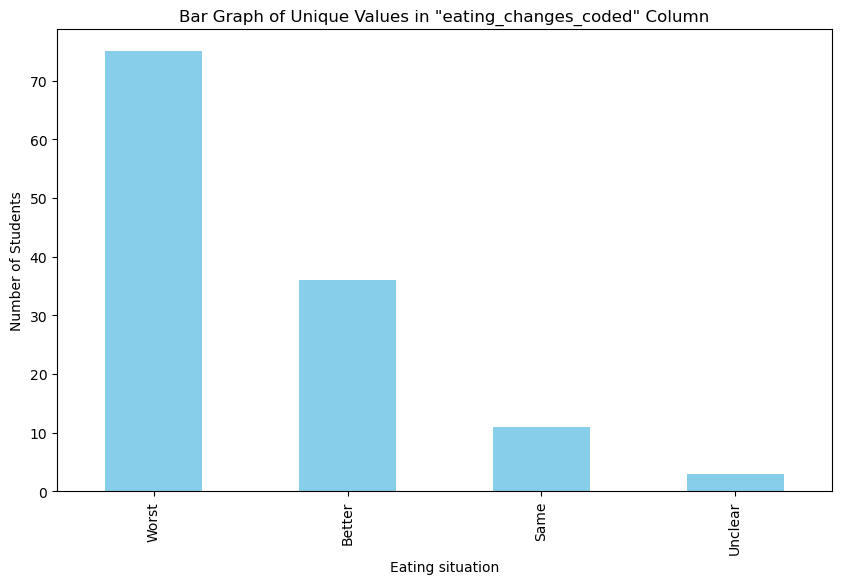

In [14]:
eating_changes_coded = 'eating_changes_coded'
df['eating_changes_coded'].value_counts().plot(kind='bar', color='skyblue', figsize=(10, 6))

plt.xlabel('Eating situation')
plt.ylabel('Number of Students')
plt.title(f'Bar Graph of Unique Values in "{eating_changes_coded}" Column')

# Display the bar graph
plt.show()

In [16]:
eating_changes_coded1 ={1:'Eat faster', 2:'Bigger Quality', 3:'Worse Quality', 4:'Same Food', 5:'Healthier', 6:'Unclear', 7:'Drink Coffee', 8:'Less Food', 9:'More Sweets', 10:'Timing', 11:'More Carbe or Snacking', 12:'Drink more Water', 13:'More Variety'}

df['eating_changes_coded1'] = df['eating_changes_coded1'].replace(eating_changes_coded1)

selected_columns = ['eating_changes_coded', 'eating_changes_coded1']
df_selected = df[selected_columns]
df_selected.head(10)

,eating_changes_coded,eating_changes_coded1
0,Worst,Eat faster
1,Worst,Bigger Quality
2,Worst,Worse Quality
3,Worst,Worse Quality
4,Same,Same Food
5,Worst,Worse Quality
6,Better,Healthier
7,Better,Healthier
8,Better,Less Food
9,Worst,Worse Quality


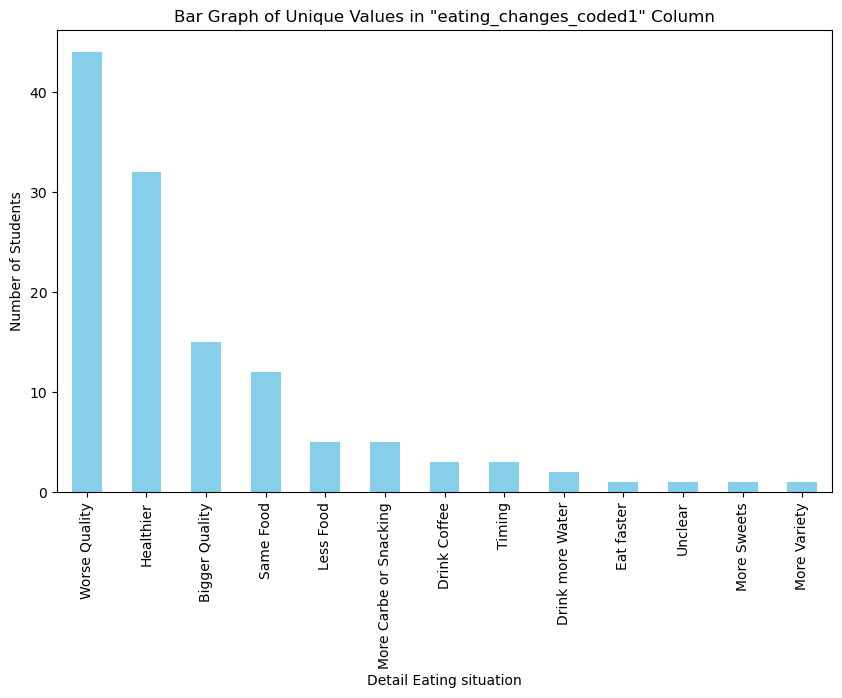

In [18]:
eating_changes_coded1 = 'eating_changes_coded1'
df['eating_changes_coded1'].value_counts().plot(kind='bar', color='skyblue', figsize=(10, 6))

plt.xlabel('Detail Eating situation')
plt.ylabel('Number of Students')
plt.title(f'Bar Graph of Unique Values in "{eating_changes_coded1}" Column')

# Display the bar graph
plt.show()

Based on the situation and detail question about the eating situation, based on the real numbers, we can clearly see that it is getting worst. Meanwhile, in the word visualization, this situation is not that visiable.

# Other habits affecting GPA
Below are the investigation of several habits that effects the overall GPA

In the very first column, **GPA**, it is an object type which means there is a mix of everything. It is better to set the column into float type. 

After setting to float type, there are missing values, strings and a few inappropriate usage. By using 'errors='coerce'', these strings are replaced by NaN. 

Finally they are filled with 0 values for better visualization in the later stage.

In [9]:
df['GPA'] = pd.to_numeric(df['GPA'], errors='coerce')
df['GPA'].replace({'Personal': pd.NA, '3.79 bitch': pd.NA, 'Unknown': pd.NA}, inplace=True)
df['GPA'].fillna(0.00, inplace=True)
df['GPA'] = df['GPA'].astype(float)

selected_columns = ['GPA', 'sports']
df_selected = df[selected_columns]
df_selected.head(65)

,GPA,sports
0,2.400,1.0
1,3.654,1.0
2,3.300,2.0
3,3.200,2.0
4,3.500,1.0
...,...,...
60,3.600,1.0
61,0.000,2.0
62,3.900,1.0
63,2.600,1.0


Now the data is cleaned for **GPA** column.

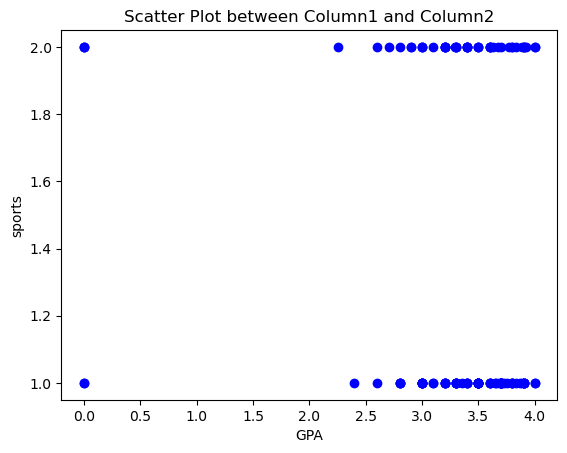

In [13]:
plt.scatter(df['GPA'], df['sports'], color='blue', marker='o')

# Adding labels and title
plt.xlabel('GPA')
plt.ylabel('sports')
plt.title('Scatter Plot between Column1 and Column2')

# Display the scatter plot
plt.show()

Observing from the scatter plot above, doing sports has a slight affect the overall GPA. (or) we can say those with higher GPA (above 3.0) do sport than those with lower grades (below 3.0)

**1 is Doing Sports** and **2 is Not doing sports**

Let's check with other habits, such as **30 fruit_day**, **45 nutritional_check**, ** 57 veggies_day**

Let's change the column **GPA** datatype into integer in order to make a box plot with other habits

In [16]:
df['GPA'] = df['GPA'].astype(int)

selected_columns = ['GPA', 'fruit_day', 'nutritional_check', 'veggies_day']
df_selected = df[selected_columns]
df_selected.head(65)

,GPA,fruit_day,nutritional_check,veggies_day
0,2,5,5,5
1,3,4,4,4
2,3,5,4,5
3,3,4,2,3
4,3,4,3,4
...,...,...,...,...
60,3,5,4,5
61,0,3,4,3
62,3,4,4,4
63,2,5,4,5


**Box Plot**

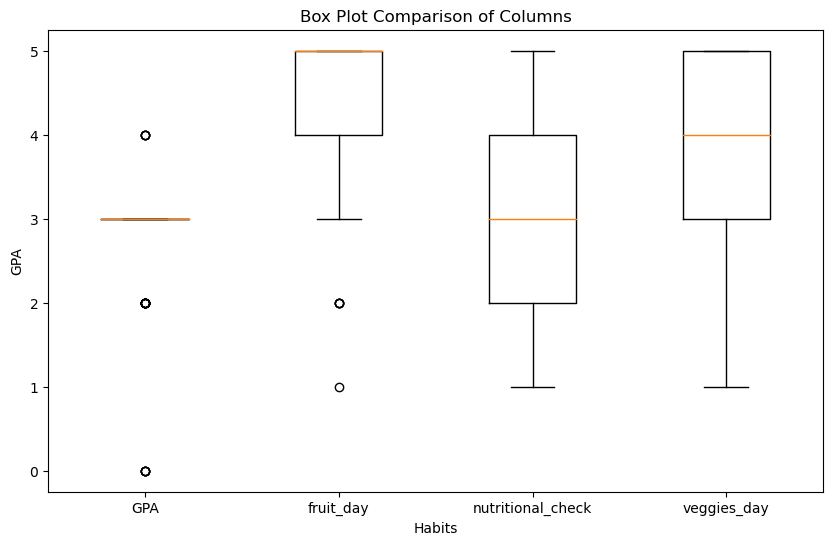

In [21]:
plt.figure(figsize=(10, 6))
plt.boxplot([df['GPA'], df['fruit_day'], df['nutritional_check'], df['veggies_day']], labels=['GPA', 'fruit_day', 'nutritional_check', 'veggies_day'])

# Adding labels and title
plt.xlabel('Habits')
plt.ylabel('GPA')
plt.title('Box Plot Comparison of Columns')

# Display the box plot
plt.show()

**Violin Plot**

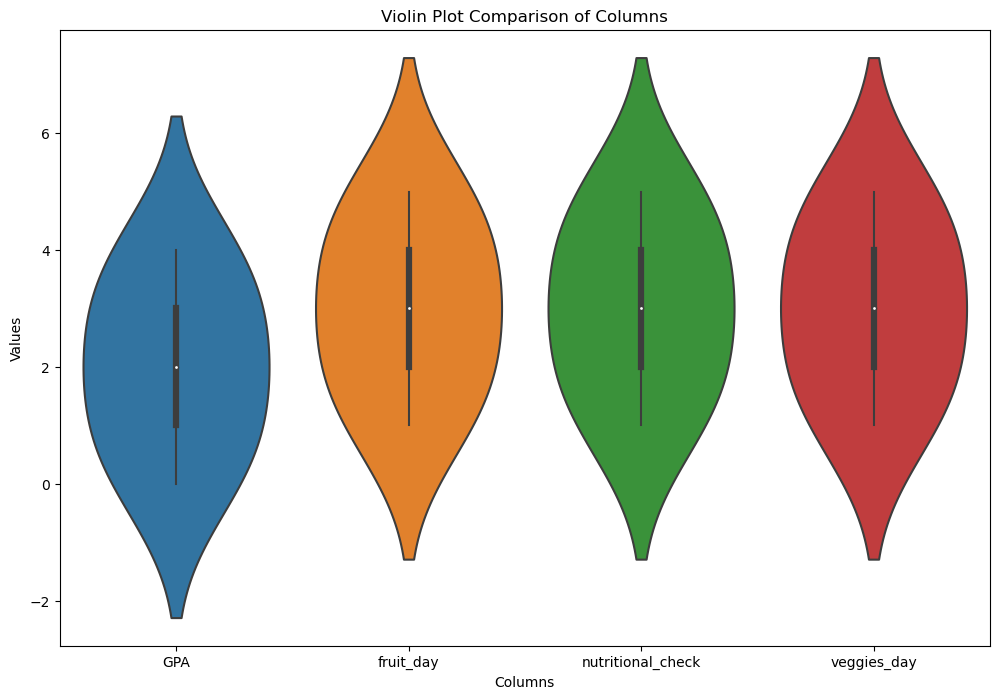

In [23]:
import seaborn as sns

data = {'GPA': [0, 1, 2, 3, 4],
        'fruit_day': [1, 2, 3, 4, 5],
        'nutritional_check': [1, 2, 3, 4, 5],
        'veggies_day': [1, 2, 3, 4, 5]}

df = pd.DataFrame(data)

# Melt the DataFrame for better visualization
df_melted = pd.melt(df, var_name='Columns', value_name='Values')

# Violin plot
plt.figure(figsize=(12, 8))
sns.violinplot(x='Columns', y='Values', data=df_melted)

# Adding labels and title
plt.xlabel('Columns')
plt.ylabel('Values')
plt.title('Violin Plot Comparison of Columns')

# Display the violin plot
plt.show()

From the box plot and violin plot above, we can witness that most students scrored 3.0 GPA, regularly eating fruits and vegetables and moderately doing the nutritional check.